In [13]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

In [14]:
from typing import Annotated, TypedDict
from langchain_core.messages import HumanMessage, BaseMessage
from dotenv import load_dotenv

In [15]:
load_dotenv()

True

In [46]:
llm = ChatOpenAI(model = "gpt-4o")

In [ ]:
# load document

loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()

In [19]:
print(f"Loaded {len(docs)} pages")

Loaded 392 pages


In [21]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size  = 1000,
    chunk_overlap =200
)

In [25]:
chunks = splitter.split_documents(docs)
print(f"Created {len(chunks)} chunks")

Created 973 chunks


In [29]:
embeddings = OpenAIEmbeddings(model = 'text-embedding-3-small')
vector_store =  FAISS.from_documents(chunks,embeddings)

In [30]:
retriever = vector_store.as_retriever(
    search_type = 'similarity',
    search_kwargs = {'k':4}
)

In [32]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [33]:
tools =  [rag_tool]
llm_with_tools =  llm.bind_tools(tools)

In [34]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [35]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [36]:
tool_node = ToolNode(tools)

In [37]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

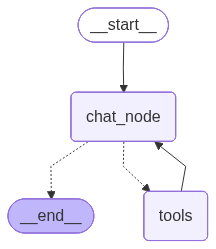

In [38]:
chatbot

In [47]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)


NotFoundError: Error code: 404 - {'error': {'message': 'The model `gpt-5o` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'param': None, 'code': 'model_not_found'}}